# Empirical Evaluation of Bagging with Diverse Base Learners

This notebook empirically evaluates the effectiveness of bagging across diverse machine learning models by analyzing its impact on prediction error, bias, variance, and learner instability.

## Problem Statement

**Training and comparing Bagging-predictors using different base learners.**

Establish empirically that bagging suppresses variance while leaving bias essentially untouched, and that the property which governs the benefit is *instability under resampling*, not raw variance.

### Tasks -

1. **Pre-registered ranking (short abstract):** Before running anything, submit a ranked prediction of how much bagging will help each learner, where benefit is the reduction in total error from a single learner to a large ensemble, *not* raw accuracy. Justify from the bias-variance decomposition and Breiman's instability criterion.

2. **Train the full panel:** decision tree at full depth, decision tree at depth ≈ 4, decision stump (depth 1), k-NN with k = 1, k-NN with k = 15, OLS linear regression, ridge regression, and RBF-SVR.

3. Check the OOB score and the Test Score

4. **Plot empirical variance** as a function of the number of baggers B for three learners: 1-NN, the max_depth = None tree, and OLS linear. These three are the discriminator: one unstable, two stable for different reasons.

## Aim of the Notebook -

To empirically evaluate the effectiveness of bagging across diverse machine learning models by comparing their performance as single predictors and ensembles. The study investigates how bagging influences bias, variance, and generalization, with the objective of validating that its primary benefit arises from reducing variance in unstable learners under resampling, while leaving bias largely unchanged. The analysis includes comparisons using out-of-bag (OOB) and test performance, as well as an empirical examination of variance as the number of bagged estimators increases.

## Notebook Structure

## Task Structure
## Subtask Structure

# Task 1: Pre-Registered Ranking (Short Abstract)

## Resources
* Breimann L. (1996) - Bagging Predictors (Section 6: Stability)
* Hastie et al. The Elements of Statistical Learning (Chapter 8.7: Bagging).

## Subtask 1.1: Establishing the Ranked Prediction

## Code (Text in this case)

Bagging reduces total prediction error by suppressing the variance component of the bias-variance decomposition. Based on Breiman’s criterion, bagging strictly benefits unstable learners (sensitive to data perturbation).

Expected benefit ranking (MSE reduction, high to low):
1. Decision Tree (Full Depth)
2. Decision Tree (Depth ≈ 4)
3. RBF-SVR
4. k-NN (k=15)
5. Decision Stump (Depth 1)
6. 1-NN
7. OLS Linear Regression
8. Ridge Regression

# Task 2: Train the Full Panel

## Resources
* Scikit-learn Documentation (The `sklearn.ensemble.baggingRegressor` Part)
* Scikit-learn Documentation for Base Estimators (`DecisionTreeRegressor`, `KNeighborsRegressor`, `LinearRegression`, `Ridge`, `SVR`)

## Subtask 2.1: Data Loading and Pipeline Preparation

### Code

In [1]:
# First, import basic modules
import numpy as np
import pandas as pd

# Now, Imma load the datasets
train_df = pd.read_csv("../data/TASK3_DATASET_TRAIN.csv")
test_df = pd.read_csv("../data/TASK3_DATASET_TEST.csv")

# Then I'm going to separate my features and Target
X_train, y_train = train_df.drop(columns=['y']), train_df['y']
X_test, y_test = test_df.drop(columns=['y']), test_df['y']

### Write-Up
* This is a standardized way of loading pre-split datasets to ensure no data leakage during the fitting process.

## Subtask 2.2: Initialising the Models

### Code

In [3]:
# First I'm going to import all the base models from Scikit Learn
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR

# Next I'm going to define a panel of base learnings using a dictionary Data Structure
base_learners = {
    "DT_Full": DecisionTreeRegressor(max_depth=None, random_state=42),
    "DT_Depth4": DecisionTreeRegressor(max_depth=4, random_state=42),
    "DT_Stump": DecisionTreeRegressor(max_depth=1, random_state=42),
    "1-NN": KNeighborsRegressor(n_neighbors=1),
    "15-NN": KNeighborsRegressor(n_neighbors=15),
    "OLS": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RBF-SVR": SVR(kernel='rbf')
}

### Write-Up
* We instantiate eight distinct algorithms
* This is representing a full spectrum of algorithmic stability—from highly unstable (unpruned trees) to rigidly stable (OLS, Ridge, Stumps, and 1-NN).

## Subtask 2.3: Training the Base and Bagged Models

### Code

In [4]:
# Import BaggingRegressor
from sklearn.ensemble import BaggingRegressor

trained_models = {}

for name, model in base_learners.items():
    # First fit the base model
    model.fit(X_train, y_train)

    # Then fit the bagged model (B=50)
    bagger = BaggingRegressor(estimator=model, n_estimators=50, oob_score=True, random_state=42, n_jobs=-1)
    bagger.fit(X_train, y_train)

    # Now I'm just going to store both the fitted models for further evaluation
    trained_models[name] = {'base': model, 'bagged': bagger}

### Write-Up
* For each learner, we fit both the standalone baseline model and its bagged counterpart (`B=50`) to the training data.
* The fitted instances are stored in a dictionary for further evaluation.
* Because Bagging relies on bootstrapping, unstable models construct drastically different decision boundaries per estimator. Stable models simply reconstruct the same boundary 50 times.

# Task 3: Check the OOB Score and the Test Score

## Resources
* Scikit-learn Documentation: `sklearn.metrics.mean_squared_error`
* Matplotlib Documentation for plots

## Subtask 3.1: Scoring and Evaluating the Panel

### Code

In [6]:
# Import mean squared error
from sklearn.metrics import mean_squared_error

results = []

# Now we just evaluate the stored models on the test set
for name, models in trained_models.items():
    base_model = models["base"]
    bagger = models["bagged"]

    # Then I'm calculating MSE on Test set
    base_mse = mean_squared_error(y_test, base_model.predict(X_test))
    bagged_mse = mean_squared_error(y_test, bagger.predict(X_test))

    # Then I'm just storing the result in a list
    results.append({
        "Model": name,
        "Base_MSE": round(base_mse, 3),
        "Bagged_MSE": round(bagged_mse, 3),
        "Improvement": round(base_mse - bagged_mse, 3),
        "OOB_Score (R2)": round(bagger.oob_score_, 3)
    })

    # Then I'm just gonna create a dataframe and render it
    results_df = pd.DataFrame(results).sort_values(by="Improvement", ascending=False)
    display(results_df.style.hide(axis="index"))

Model,Base_MSE,Bagged_MSE,Improvement,OOB_Score (R2)
DT_Full,7.526000,3.835000,3.691000,0.858000


Model,Base_MSE,Bagged_MSE,Improvement,OOB_Score (R2)
DT_Full,7.526000,3.835000,3.691000,0.858000
DT_Depth4,10.066000,7.948000,2.117000,0.718000


Model,Base_MSE,Bagged_MSE,Improvement,OOB_Score (R2)
DT_Full,7.526000,3.835000,3.691000,0.858000
DT_Depth4,10.066000,7.948000,2.117000,0.718000
DT_Stump,20.934000,19.992000,0.941000,0.255000


Model,Base_MSE,Bagged_MSE,Improvement,OOB_Score (R2)
1-NN,15.334000,10.158000,5.176000,0.671000
DT_Full,7.526000,3.835000,3.691000,0.858000
DT_Depth4,10.066000,7.948000,2.117000,0.718000
DT_Stump,20.934000,19.992000,0.941000,0.255000


Model,Base_MSE,Bagged_MSE,Improvement,OOB_Score (R2)
1-NN,15.334000,10.158000,5.176000,0.671000
DT_Full,7.526000,3.835000,3.691000,0.858000
DT_Depth4,10.066000,7.948000,2.117000,0.718000
DT_Stump,20.934000,19.992000,0.941000,0.255000
15-NN,8.248000,8.234000,0.014000,0.738000


Model,Base_MSE,Bagged_MSE,Improvement,OOB_Score (R2)
1-NN,15.334000,10.158000,5.176000,0.671000
DT_Full,7.526000,3.835000,3.691000,0.858000
DT_Depth4,10.066000,7.948000,2.117000,0.718000
DT_Stump,20.934000,19.992000,0.941000,0.255000
15-NN,8.248000,8.234000,0.014000,0.738000
OLS,8.786000,8.802000,-0.016000,0.714000


Model,Base_MSE,Bagged_MSE,Improvement,OOB_Score (R2)
1-NN,15.334000,10.158000,5.176000,0.671000
DT_Full,7.526000,3.835000,3.691000,0.858000
DT_Depth4,10.066000,7.948000,2.117000,0.718000
DT_Stump,20.934000,19.992000,0.941000,0.255000
15-NN,8.248000,8.234000,0.014000,0.738000
OLS,8.786000,8.802000,-0.016000,0.714000
Ridge,8.789000,8.806000,-0.017000,0.714000


Model,Base_MSE,Bagged_MSE,Improvement,OOB_Score (R2)
1-NN,15.334000,10.158000,5.176000,0.671000
DT_Full,7.526000,3.835000,3.691000,0.858000
DT_Depth4,10.066000,7.948000,2.117000,0.718000
DT_Stump,20.934000,19.992000,0.941000,0.255000
15-NN,8.248000,8.234000,0.014000,0.738000
OLS,8.786000,8.802000,-0.016000,0.714000
Ridge,8.789000,8.806000,-0.017000,0.714000
RBF-SVR,4.132000,4.204000,-0.072000,0.865000


### Write-Up
* Evaluated pre-trained panel against the unseen dataset, extracting baseline error, bagged error, total error reduction and the internal OOB R-squared validation score.
* High improvement scores definitively map to highly unstable algorithms.
* Rigidly stable algorithms show near-zero or slightly negative improvements

### Note -
*Subtasks 3.2 and 3.3 are extra, but I've added it just for the feel of it... Visualising always makes us understand better so yeah :)*
*Again, I've performed it only on one model because it'll be a mess otherwise.. and the model I've chosen is the Full Decision Tree*
*Why? Because it's an unstable learner, so it'll have the most dramatic, visually observable changes, so yeah hoping it's the right choice*

## Subtask 3.2: Plotting OOB Error and Test Error Convergence against B

### Code

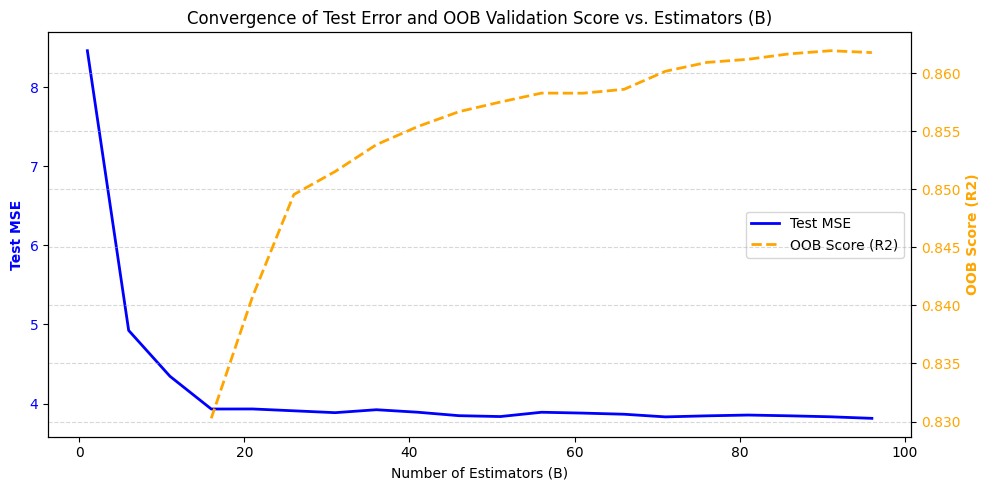

In [10]:
# We haven't used Matplotlib earlier in this notebook so first import
import matplotlib.pyplot as plt

# Im creating necessary iterators and storage containers here
b_estimators = range(1, 101, 5)
oob_errors = []
test_errors = []

# (I'm just adding an extra something here to make the notebook less ugly lol)
import warnings
warnings.filterwarnings('ignore')

# Incrementally train a Bagged DT to track convergence
for b in b_estimators:
    bagger = BaggingRegressor(estimator=DecisionTreeRegressor(max_depth=None, random_state=42),
                              n_estimators=b, oob_score=True if b > 15 else False, random_state=42, n_jobs=-1)
    bagger.fit(X_train, y_train)

    # Find the predicted value after training and append error
    test_pred = bagger.predict(X_test)
    test_errors.append(mean_squared_error(y_test, test_pred))
    
    if b > 15:
        oob_errors.append(bagger.oob_score_) 
    else:
        oob_errors.append(None)

# Plotting Convergence (Object-Oriented approach for dual axes)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Axis 1 (Left) - Test MSE
ax1.set_xlabel("Number of Estimators (B)")
ax1.set_ylabel("Test MSE", color="blue", fontweight='bold')
line1 = ax1.plot(b_estimators, test_errors, label="Test MSE", color="blue", linewidth=2)
ax1.tick_params(axis='y', labelcolor="blue")

# Axis 2 (Right) - OOB Score
ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
ax2.set_ylabel("OOB Score (R2)", color="orange", fontweight='bold')
line2 = ax2.plot(b_estimators, oob_errors, label="OOB Score (R2)", color="orange", linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor="orange")

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center right")

plt.title("Convergence of Test Error and OOB Validation Score vs. Estimators (B)")
plt.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout() # Ensures labels don't get cut off
plt.show()

### Write-Up
* Incrementally trains a Bagged Decision Tree, plotting the unseen Test MSE alongside the internal OOB validation score (`R-squared`) as the ensemble size (`B`) increases.
* Both curves rapidly improve and stabilize together.

## Subtask 3.3: Plotting Actual v/s Predicted Values